data_set: https://www.kaggle.com/datasets/yasserh/uber-fares-dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy import stats

In [2]:
df = pd.read_csv(r"C:\Eni data\PYTHON\PYTHON CODES & PROJECTS\Datasets\NYC_UberRidedata.csv")
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [3]:
summary = (
    pd.DataFrame({
        'dtype': df.dtypes,
        'non_null': df.notna().sum(),
        'nulls': df.isna().sum(),
        'null_%': (df.isna().mean() * 100).round(2),
        'unique': df.nunique(),
    })
    .sort_values('null_%', ascending=False)
)
print(summary)

                     dtype  non_null  nulls  null_%  unique
Unnamed: 0           int64    200000      0     0.0  200000
key                 object    200000      0     0.0  200000
fare_amount        float64    200000      0     0.0    1244
pickup_datetime     object    200000      0     0.0  196629
pickup_longitude   float64    200000      0     0.0   71066
pickup_latitude    float64    200000      0     0.0   83835
dropoff_longitude  float64    199999      1     0.0   76894
dropoff_latitude   float64    199999      1     0.0   90585
passenger_count      int64    200000      0     0.0       8


In [4]:
print(f"(rows,columns): {df.shape}")
print(f"duplicated_count: {df.duplicated().sum()}")

(rows,columns): (200000, 9)
duplicated_count: 0


### Data Cleaning

In [5]:
# dropping the rows with nulls
df.dropna(inplace = True) 

# drop the "unnamed_0" column 
df.drop('Unnamed: 0', axis = 1, inplace =True)

# Remove invalid coordinates 
df = df[
    (df['pickup_longitude'] != 0) &
    (df['pickup_latitude'] != 0) &
    (df['dropoff_longitude'] != 0) &
    (df['dropoff_latitude'] != 0) &
    (df['pickup_longitude'].between(-75, -72)) &
    (df['dropoff_longitude'].between(-75, -72)) &
    (df['pickup_latitude'].between(40, 42)) &
    (df['dropoff_latitude'].between(40, 42))
]
# Remove invalid fare_amount and passenger count
df = df[(df['fare_amount'] > 0) & (df['passenger_count'] > 0) & (df['passenger_count'] <= 6)]

#Convert datetime format
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime']) 


In [6]:
df['fare_amount'].describe()

count    195100.000000
mean         11.350275
std           9.802850
min           0.010000
25%           6.000000
50%           8.500000
75%          12.500000
max         499.000000
Name: fare_amount, dtype: float64

<Axes: xlabel='fare_amount', ylabel='Density'>

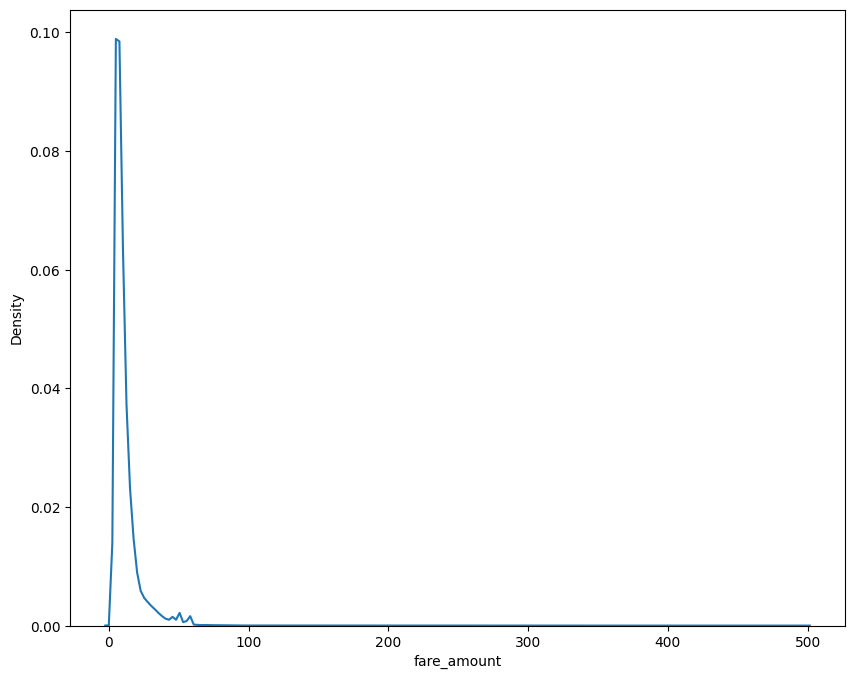

In [7]:
plt.figure(figsize=(10,8))
sns.kdeplot(df['fare_amount'])

In [8]:
df['fare_amount'].quantile([0.90, 0.95, 0.99, 0.999])

0.900    20.50000
0.950    30.27000
0.990    52.83070
0.999    79.97525
Name: fare_amount, dtype: float64

In [9]:
# Convert UTC time format to New York local time format before extracting time-based features
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], utc=True)
df['pickup_datetime_ny'] = df['pickup_datetime'].dt.tz_convert('America/New_York')

# Extract hour (NY local time)
df['hour of day'] = df['pickup_datetime_ny'].dt.hour

# Extract day of week (NY local time)
df['day of week'] = df['pickup_datetime_ny'].dt.day_name()

# Extract month (NY local time)
df['month'] = df['pickup_datetime_ny'].dt.month

# Extract year (NY local time)
df['year'] = df['pickup_datetime_ny'].dt.year


In [10]:
# Distance_km using Haversine formula
# Convert latitude and longitude to radians
lat1 = np.radians(df['pickup_latitude'])
lon1 = np.radians(df['pickup_longitude'])
lat2 = np.radians(df['dropoff_latitude'])
lon2 = np.radians(df['dropoff_longitude'])

# Haversine formula to calculate distance in kilometers
df['distance_km'] = 6371 * 2 * np.arcsin(
    np.sqrt(
        np.sin((lat2 - lat1)/2)**2 +
        np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1)/2)**2
    )
)
df["distance_km"] = df["distance_km"].round(3).astype(float)


In [11]:
# First lets remove distance which is zero
df = df[df['distance_km'] > 0]

In [12]:
# To remove invalid value combination of distance and fare, we will use fare_per_km feature
df['fare_per_km'] = (
    df['fare_amount'] / df['distance_km']
)


In [13]:
df['fare_per_km'].describe(percentiles=[0.001, 0.002, 0.90,0.95,0.99,0.991, 0.993, 0.995])

count    192977.000000
mean         31.809277
std        1602.954382
min           0.001402
0.1%          0.643943
0.2%          0.987838
50%           3.821197
90%           6.807867
95%           8.547009
99%          23.988782
99.1%        27.627956
99.3%        42.586488
99.5%        83.333333
max      499000.000000
Name: fare_per_km, dtype: float64

In [14]:
# extreme corruption starts AFTER the 99th percentile.
upper = df['fare_per_km'].quantile(0.991)
lower = df['fare_per_km'].quantile(0.001)

df = df[
    (df['fare_per_km'] <= upper) &
    (df['fare_per_km'] > lower)
]

In [15]:
print(df['fare_amount'].min())
print(df['fare_amount'].max())

0.01
230.0


In [16]:
df['fare_amount'].describe(percentiles=[0.0001, 0.002, 0.90,0.95,0.99,0.991, 0.993, 0.999])

count    191047.000000
mean         11.300386
std           9.446155
min           0.010000
0.01%         2.500000
0.2%          2.900000
50%           8.500000
90%          20.100000
95%          29.850000
99%          52.000000
99.1%        54.500000
99.3%        57.330000
99.9%        75.000000
max         230.000000
Name: fare_amount, dtype: float64

In [17]:
upper_fare = df['fare_amount'].quantile(0.999)
lower_fare = df['fare_amount'].quantile(0.0001)
df = df[(df['fare_amount'] <= upper_fare) & (df['fare_amount'] >= lower_fare)]

In [18]:
df.shape # almost 10,000 rows is removed due to invalid values.

(190860, 15)

#### NOTES: Data cleaning reasonings

1. Removed null values and unnecessary index-style columns such as `Unnamed: 0`.

2. Removed invalid GPS coordinates such as `(0, 0)` and retained only trips inside broad NYC-area latitude/longitude bounds. This prevents corrupted coordinates from creating impossible trip distances.

3. Kept realistic passenger counts only: `passenger_count > 0` and `passenger_count <= 6`. This matches practical ride-capacity limits and removes invalid records.

4. Converted `pickup_datetime` from UTC to New York local time before extracting `hour of day`, `day of week`, `month`, and `year`. This is important because demand and peak-hour behavior must reflect NYC local time, not UTC time.

5. Calculated `distance_km` using the Haversine formula because pickup/dropoff coordinates are geographic latitude-longitude points.

6. Removed rows where `fare_amount <= 0` or `distance_km <= 0`, since these are not meaningful for fare prediction.

7. Avoided aggressive IQR-based outlier removal because taxi/ride fares are naturally right-skewed. Legitimate airport rides, long rides, and unusual traffic situations can create high but valid fares.

8. Created `fare_per_km` only as a temporary cleaning diagnostic to detect inconsistent fare-distance combinations, such as very high fares for nearly zero distance or very long rides with unrealistically low fares.

9. Used percentile-based filtering on `fare_per_km` and `fare_amount` to remove extreme corrupted records while preserving realistic long-tail trips.

10. Dropped `fare_per_km` before machine learning because it directly uses `fare_amount`, the prediction target. Keeping it would cause target leakage and produce unrealistic model performance.

11. Overall, the cleaning process keeps the dataset realistic, avoids over-removing valid business cases, and prepares the data for trustworthy EDA, hypothesis testing, and model development.


In [19]:
df.columns

Index(['key', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count', 'pickup_datetime_ny', 'hour of day', 'day of week',
       'month', 'year', 'distance_km', 'fare_per_km'],
      dtype='object')

### Feature Engineering


#### Time and Route Enrichment
These engineered features add temporal structure, route geometry, and airport context that are often important for ride-pricing behavior.


In [20]:
# 1) Weekend indicator (Saturday/Sunday = 1, else 0)
df['is_weekend'] = df['day of week'].isin(['Saturday', 'Sunday']).astype(int)

# 2) Cyclic time encoding to preserve circular nature of hour/month
df['hour_sin'] = np.sin(2 * np.pi * df['hour of day'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour of day'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# 3) + 4) Coordinate deltas
df['delta_latitude'] = (df['dropoff_latitude'] - df['pickup_latitude']).abs()
df['delta_longitude'] = (df['dropoff_longitude'] - df['pickup_longitude']).abs()

# 5) Airport trip flag
# Reasoning: airport rides often have different distance profiles, toll behavior, and pricing patterns.
airports = {
    'JFK': (40.6413, -73.7781),
    'LGA': (40.7769, -73.8740),
    'EWR': (40.6895, -74.1745)
}

def haversine_km(lat1, lon1, lat2, lon2):
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 6371.0 * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

pickup_airport_dist = np.vstack([
    haversine_km(df['pickup_latitude'], df['pickup_longitude'], lat, lon)
    for lat, lon in airports.values()
])
dropoff_airport_dist = np.vstack([
    haversine_km(df['dropoff_latitude'], df['dropoff_longitude'], lat, lon)
    for lat, lon in airports.values()
])

df['pickup_airport_min_km'] = pickup_airport_dist.min(axis=0)
df['dropoff_airport_min_km'] = dropoff_airport_dist.min(axis=0)

# A ~2.5 km radius captures airport terminals + immediate approach roads.
airport_radius_km = 2.5
df['airport_trip'] = (
    (df['pickup_airport_min_km'] <= airport_radius_km) |
    (df['dropoff_airport_min_km'] <= airport_radius_km)
).astype(int)

df[['is_weekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'delta_latitude', 'delta_longitude', 'airport_trip']].head()


,is_weekend,hour_sin,hour_cos,month_sin,month_cos,delta_latitude,delta_longitude,airport_trip
0,0,-0.707107,-0.707107,5.000000e-01,-0.866025,0.015137,0.000305,0
1,0,-0.866025,-0.500000,-5.000000e-01,-0.866025,0.022100,0.000355,0
2,0,-0.965926,-0.258819,-8.660254e-01,-0.500000,0.031877,0.042478,0
3,0,0.866025,0.500000,1.224647e-16,-1.000000,0.012505,0.010808,0
4,0,-0.258819,-0.965926,-8.660254e-01,-0.500000,0.017162,0.048059,0


#### Region-Based Clustering Features
Clustering pickup and dropoff points helps capture zone-level fare behavior (dense business districts, airports, residential areas, etc.) that raw latitude/longitude alone may not represent efficiently.


In [21]:
from sklearn.cluster import KMeans

n_clusters = 20

pickup_kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
dropoff_kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

df['pickup_cluster'] = pickup_kmeans.fit_predict(df[['pickup_latitude', 'pickup_longitude']])
df['dropoff_cluster'] = dropoff_kmeans.fit_predict(df[['dropoff_latitude', 'dropoff_longitude']])

df[['pickup_cluster', 'dropoff_cluster']].nunique()


pickup_cluster     20
dropoff_cluster    20
dtype: int64

#### Demand-Based Peak-Hour Feature
Peak hours are created from trip frequency only, using New York local time. This avoids target leakage because `fare_amount` is not used to define the feature.


In [22]:
# Build peak-hour signal from observed demand only (no fare_amount usage -> no target leakage).
hourly_demand = (
    df.groupby('hour of day', as_index=False)
      .agg(trip_count=('key', 'count'))
      .sort_values('hour of day')
)

peak_threshold = hourly_demand['trip_count'].quantile(0.75)
peak_hours = sorted(hourly_demand.loc[hourly_demand['trip_count'] >= peak_threshold, 'hour of day'].tolist())

df['is_peak_hour'] = df['hour of day'].isin(peak_hours).astype(int)

print(f'Peak hours identified from demand (NY local time): {peak_hours}')
hourly_demand


Peak hours identified from demand (NY local time): [13, 14, 15, 16, 17, 18]


,hour of day,trip_count
0,0,2097
1,1,2528
2,2,4967
3,3,7453
4,4,8875
5,5,8831
6,6,8724
7,7,9164
8,8,9561
9,9,9435


#### Feature Explanation

- `is_weekend`: Marks Saturday and Sunday rides as 1. Weekend ride behavior can differ from weekday commute behavior.
- `hour_sin` and `hour_cos`: Encode hour as a cycle. This helps models understand that 23:00 and 00:00 are close in time.
- `month_sin` and `month_cos`: Encode month seasonality as a cycle. December and January are close in a yearly cycle.
- `delta_latitude` and `delta_longitude`: Capture the absolute north-south and east-west movement of the trip. These support distance and route-shape understanding.
- `pickup_airport_min_km`: Distance from the pickup point to the nearest major airport among JFK, LaGuardia, and Newark. This helps identify rides starting near airport zones, even if they are not exactly inside the airport boundary.
- `dropoff_airport_min_km`: Distance from the dropoff point to the nearest major airport among JFK, LaGuardia, and Newark. This helps identify rides ending near airport zones.
- `airport_trip`: Binary flag showing whether pickup or dropoff is within the selected airport radius. It turns airport proximity into an easy-to-interpret business feature.
- `pickup_cluster`: KMeans-based geographic zone label created from pickup latitude and longitude. It captures pickup-area behavior such as business districts, residential areas, or airport-like regions.
- `dropoff_cluster`: KMeans-based geographic zone label created from dropoff latitude and longitude. It captures destination-zone behavior that can influence fare patterns.
- `is_peak_hour`: Created from ride demand only, using New York local time. It is not based on `fare_amount`, so it avoids target leakage.

For Tableau, some ML-oriented features such as sine/cosine encodings and coordinate deltas are not very useful visually. The Tableau export cell below keeps dashboard-friendly columns separately.


#### Peak-Hour Modeling Note
The EDA dataframe already has a demand-based `is_peak_hour` feature for analysis. In the machine learning section, this feature is rebuilt from the training split only and then applied to the test split, which keeps the final modeling pipeline leakage-safe.


### EDA

                 fare_amount  distance_km  passenger_count
fare_amount         1.000000     0.919133         0.015376
distance_km         0.919133     1.000000         0.009169
passenger_count     0.015376     0.009169         1.000000


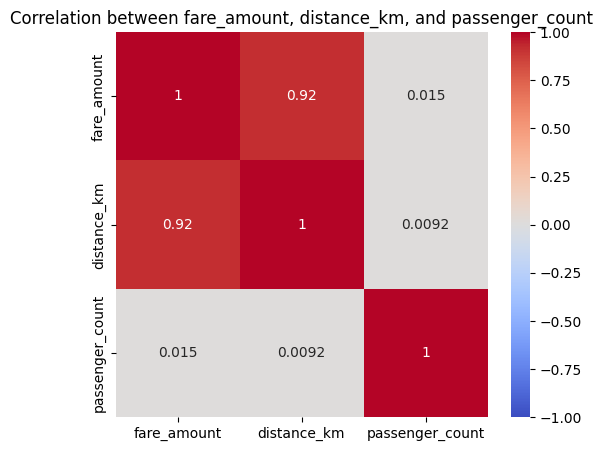

In [23]:
corr = df[['fare_amount', 'distance_km', 'passenger_count']].corr()
print(corr)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation between fare_amount, distance_km, and passenger_count')
plt.show()

#### Distance vs Fare Relationship


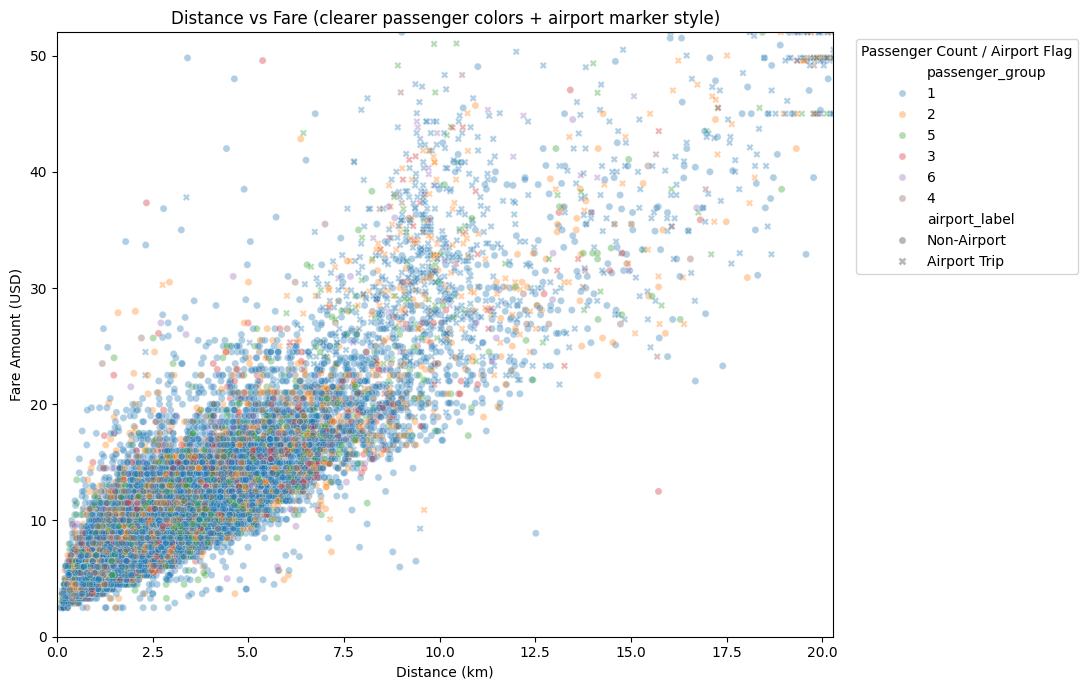

In [24]:
# Visualization sample only for readability/performance; does NOT modify df
scatter_sample = df.sample(min(25000, len(df)), random_state=42).copy()
scatter_sample['airport_label'] = np.where(scatter_sample['airport_trip'] == 1, 'Airport Trip', 'Non-Airport')
scatter_sample['passenger_group'] = scatter_sample['passenger_count'].astype(int).astype(str)

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=scatter_sample,
    x='distance_km',
    y='fare_amount',
    hue='passenger_group',
    style='airport_label',
    alpha=0.35,
    s=26,
    palette='tab10'
)
# Axis limits use 99th percentile only to reduce long-tail compression in the chart
# (display choice only; underlying cleaned dataframe remains unchanged).
plt.xlim(0, scatter_sample['distance_km'].quantile(0.99))
plt.ylim(0, scatter_sample['fare_amount'].quantile(0.99))
plt.title('Distance vs Fare (clearer passenger colors + airport marker style)')
plt.xlabel('Distance (km)')
plt.ylabel('Fare Amount (USD)')
plt.legend(title='Passenger Count / Airport Flag', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Observation:**
- Fare generally increases with trip distance, with wider variance on longer routes.
- Airport-tagged trips tend to appear more in medium-to-long distance ranges.
- Passenger count has a weaker direct effect than distance, but segment-level differences are visible.


#### Fare Distributions Across Weekends and Airport Trips


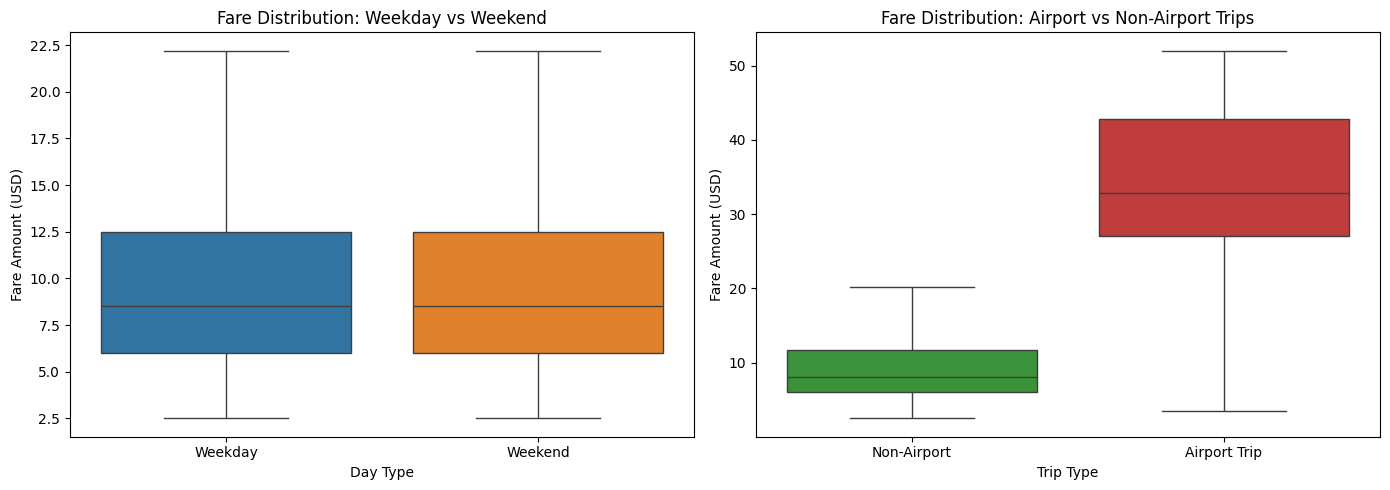

In [25]:
# 99th-percentile cap is for cleaner boxplot readability only (no change to main df).
fare_plot = df[df['fare_amount'] <= df['fare_amount'].quantile(0.99)].copy()
fare_plot['day_type'] = np.where(fare_plot['is_weekend'] == 1, 'Weekend', 'Weekday')
fare_plot['airport_type'] = np.where(fare_plot['airport_trip'] == 1, 'Airport Trip', 'Non-Airport')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=fare_plot,
    x='day_type',
    y='fare_amount',
    hue='day_type',
    palette={'Weekday': '#1f77b4', 'Weekend': '#ff7f0e'},
    legend=False,
    showfliers=False,
    ax=axes[0]
)
axes[0].set_title('Fare Distribution: Weekday vs Weekend')
axes[0].set_xlabel('Day Type')
axes[0].set_ylabel('Fare Amount (USD)')

sns.boxplot(
    data=fare_plot,
    x='airport_type',
    y='fare_amount',
    hue='airport_type',
    palette={'Non-Airport': '#2ca02c', 'Airport Trip': '#d62728'},
    legend=False,
    showfliers=False,
    ax=axes[1]
)
axes[1].set_title('Fare Distribution: Airport vs Non-Airport Trips')
axes[1].set_xlabel('Trip Type')
axes[1].set_ylabel('Fare Amount (USD)')

plt.tight_layout()
plt.show()


**Observation:**
- Weekend and weekday fare distributions can differ in spread, indicating demand/traffic mix changes.
- Airport trips typically show a higher fare distribution than non-airport rides.


#### Passenger Count vs Fare


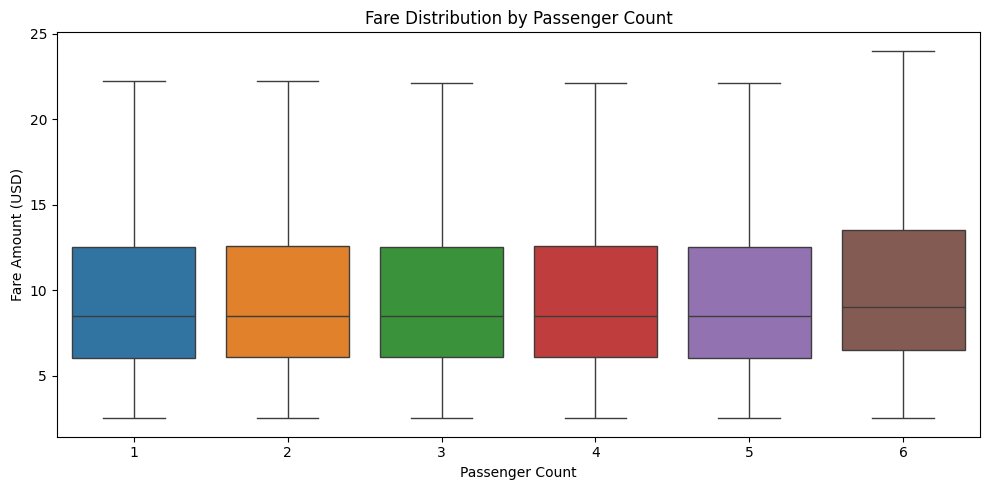

In [26]:
# Capped copy for readability only; the core cleaned dataframe is unchanged.
passenger_plot = df[df['fare_amount'] <= df['fare_amount'].quantile(0.99)].copy()

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=passenger_plot,
    x='passenger_count',
    y='fare_amount',
    hue='passenger_count',
    palette='tab10',
    legend=False,
    showfliers=False
)
plt.title('Fare Distribution by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount (USD)')
plt.tight_layout()
plt.show()


**Observation:**
- Median fare differences by passenger count are modest compared with distance-driven effects.
- Passenger count still provides segmentation value when combined with route/time features.


#### Hour-of-Day Demand and Fare Behavior


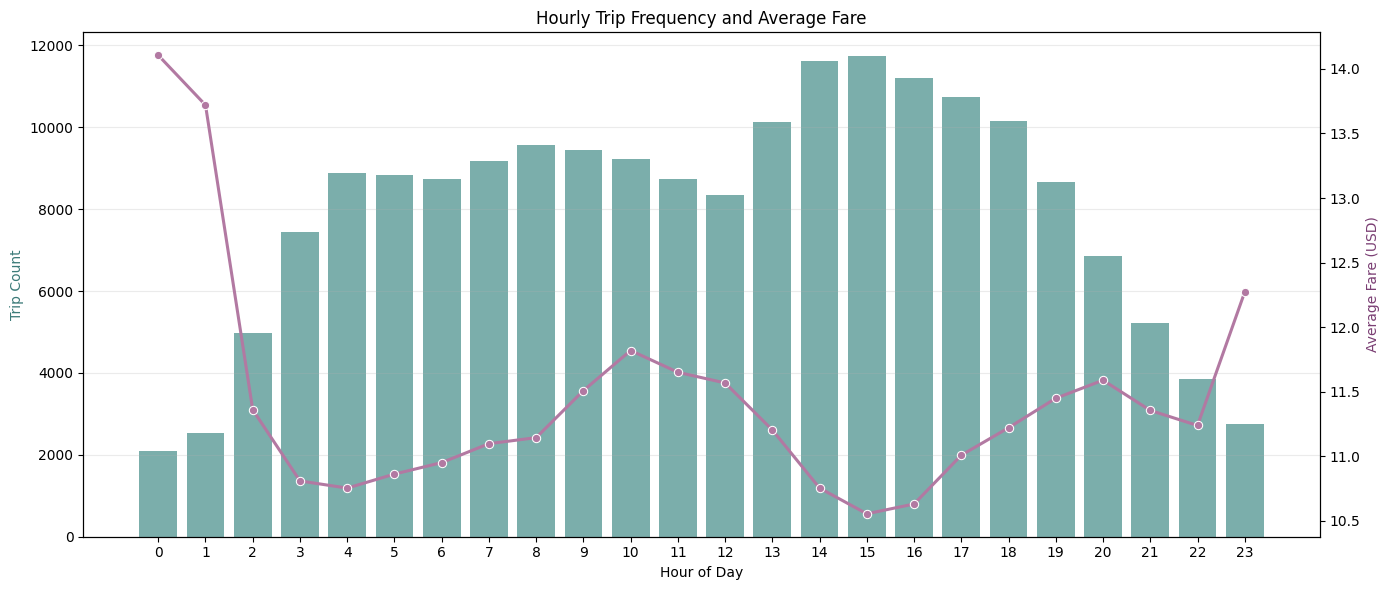

,hour of day,trip_count,avg_fare
0,0,2097,14.105227
1,1,2528,13.719581
2,2,4967,11.360503
3,3,7453,10.809698
4,4,8875,10.754269


In [27]:
hourly_profile = (
    df.groupby('hour of day', as_index=False)
      .agg(
          trip_count=('key', 'count'),
          avg_fare=('fare_amount', 'mean')
      )
      .sort_values('hour of day')
)

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

sns.barplot(data=hourly_profile, x='hour of day', y='trip_count', color='#72B7B2', ax=ax1)
sns.lineplot(data=hourly_profile, x='hour of day', y='avg_fare', marker='o', color='#B279A2', linewidth=2.2, ax=ax2)

ax1.set_title('Hourly Trip Frequency and Average Fare')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Trip Count', color='#3B7A78')
ax2.set_ylabel('Average Fare (USD)', color='#7A3E73')
ax1.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

hourly_profile.head()


**Observation:**
- After converting UTC to New York local time, ride demand is concentrated mainly from early afternoon to early evening.
- This hourly demand pattern supports the demand-based `is_peak_hour` feature created in Feature Engineering.


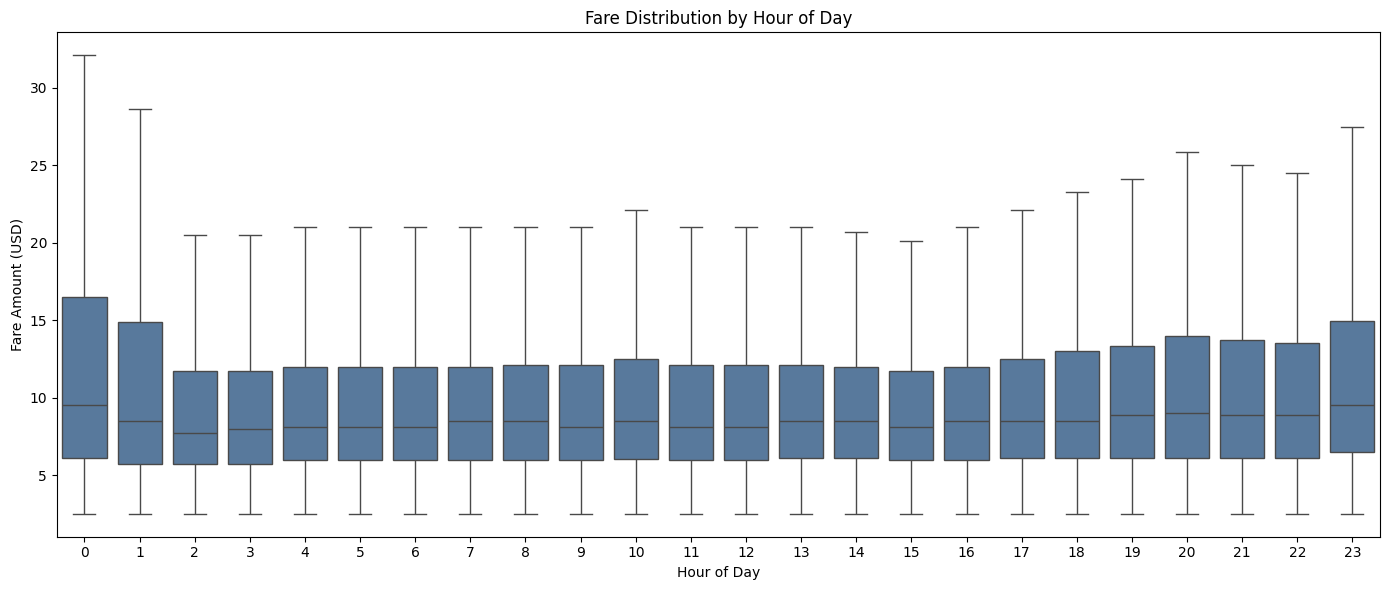

In [28]:
# Capped copy for visualization clarity only; original cleaned df is unchanged.
hourly_fare = df[df['fare_amount'] <= df['fare_amount'].quantile(0.99)].copy()

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=hourly_fare,
    x='hour of day',
    y='fare_amount',
    showfliers=False,
    color='#4C78A8'
)
plt.title('Fare Distribution by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Fare Amount (USD)')
plt.tight_layout()
plt.show()


**Observation:**
- Fare dispersion is not uniform across the day, suggesting time-driven pricing variability.


#### Multi-Feature Business Insight


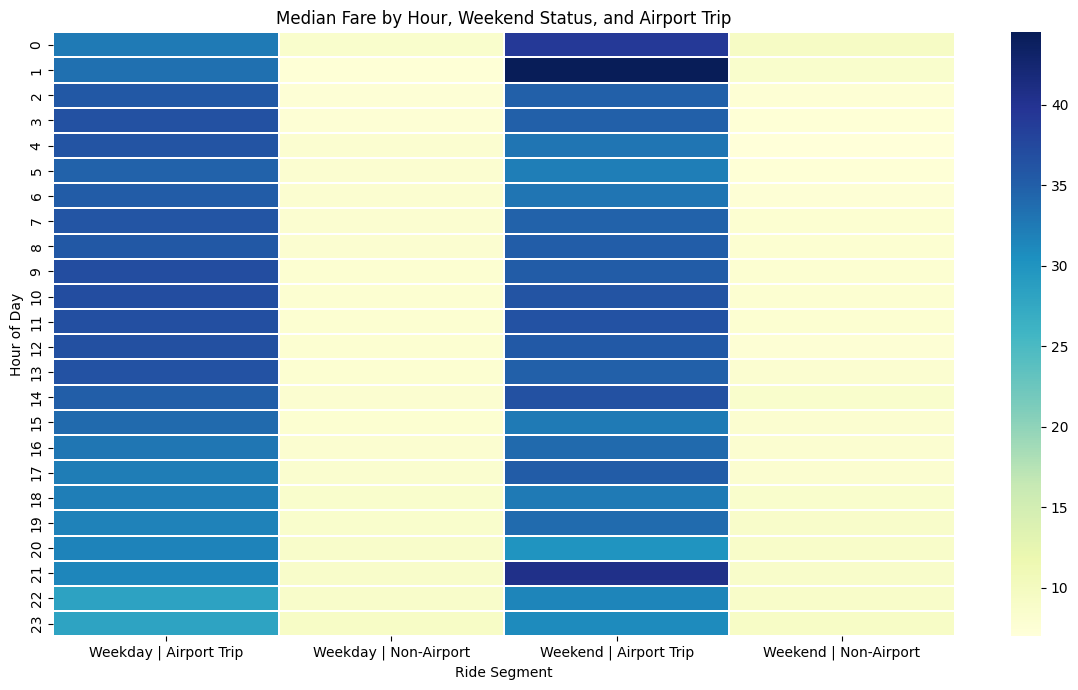

In [29]:
multi_view = df.copy()
multi_view['day_type'] = np.where(multi_view['is_weekend'] == 1, 'Weekend', 'Weekday')
multi_view['airport_type'] = np.where(multi_view['airport_trip'] == 1, 'Airport Trip', 'Non-Airport')
multi_view['segment'] = multi_view['day_type'] + ' | ' + multi_view['airport_type']

segment_heatmap = (
    multi_view.pivot_table(
        index='hour of day',
        columns='segment',
        values='fare_amount',
        aggfunc='median'
    )
    .sort_index()
)

plt.figure(figsize=(12, 7))
sns.heatmap(segment_heatmap, cmap='YlGnBu', linewidths=0.3)
plt.title('Median Fare by Hour, Weekend Status, and Airport Trip')
plt.xlabel('Ride Segment')
plt.ylabel('Hour of Day')
plt.tight_layout()
plt.show()


**Observation:**
- Airport segments tend to remain costlier across most hours.
- The heatmap highlights when weekend/weekday effects amplify or narrow fare gaps.


#### Leakage-Safe Modeling Preparation


In [30]:
# `fare_per_km` was created using `fare_amount` (the prediction target).
# Keeping it as a model input would leak target information and inflate model performance unrealistically.
if 'fare_per_km' in df.columns:
    df.drop(columns=['fare_per_km'], inplace=True)

df.head()


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_ny,hour of day,...,month_sin,month_cos,delta_latitude,delta_longitude,pickup_airport_min_km,dropoff_airport_min_km,airport_trip,pickup_cluster,dropoff_cluster,is_peak_hour
0,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015-05-07 15:52:06-04:00,15,...,5.000000e-01,-0.866025,0.015137,0.000305,11.431237,12.141485,0,11,2,1
1,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009-07-17 16:04:56-04:00,16,...,-5.000000e-01,-0.866025,0.022100,0.000355,11.492311,10.586969,0,1,16,1
2,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009-08-24 17:45:00-04:00,17,...,-8.660254e-01,-0.500000,0.031877,0.042478,11.745680,7.472683,0,11,3,1
3,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009-06-26 04:22:21-04:00,4,...,1.224647e-16,-1.000000,0.012505,0.010808,8.736955,8.230935,0,18,19,0
4,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014-08-28 13:47:00-04:00,13,...,-8.660254e-01,-0.500000,0.017162,0.048059,5.637512,8.523615,0,6,9,1


In [31]:
list(df.columns)

['key',
 'fare_amount',
 'pickup_datetime',
 'pickup_longitude',
 'pickup_latitude',
 'dropoff_longitude',
 'dropoff_latitude',
 'passenger_count',
 'pickup_datetime_ny',
 'hour of day',
 'day of week',
 'month',
 'year',
 'distance_km',
 'is_weekend',
 'hour_sin',
 'hour_cos',
 'month_sin',
 'month_cos',
 'delta_latitude',
 'delta_longitude',
 'pickup_airport_min_km',
 'dropoff_airport_min_km',
 'airport_trip',
 'pickup_cluster',
 'dropoff_cluster',
 'is_peak_hour']

#### Optional Tableau Export
This export is commented out by default. Remove the `#` symbols only when you want to create a dashboard CSV. The Tableau file keeps dashboard-friendly fields such as `key`, fare, distance, passenger count, local time fields, airport flag, weekend flag, peak-hour flag, and clusters. It excludes ML-only helper columns such as sine/cosine encodings and coordinate deltas.


In [32]:
tableau_cols = [
    'key', 'fare_amount', 'pickup_datetime', 'pickup_datetime_ny',
    'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
    'passenger_count', 'distance_km', 'hour of day', 'day of week', 'month', 'year',
    'is_weekend', 'is_peak_hour', 'airport_trip',
    'pickup_airport_min_km', 'dropoff_airport_min_km',
    'pickup_cluster', 'dropoff_cluster'
]
tableau_df = df[[col for col in tableau_cols if col in df.columns]].copy()
tableau_df.to_csv(r'C:\Eni data\PYTHON\PYTHON CODES & PROJECTS\Datasets\uber_fare_tableau_ready.csv', index=False)
print('Tableau CSV exported:', tableau_df.shape)


Tableau CSV exported: (190860, 21)


### Hypothesis Testing
EDA gave us useful patterns. This section checks which patterns are statistically reliable and business-meaningful.


#### Test 1: Controlled Airport Premium Test
**Statistical test used:** Multiple Linear Regression using OLS with HC3 robust standard errors.

**Simple explanation:** OLS regression estimates the effect of one feature while holding other features constant. HC3 robust standard errors are used because fare data is noisy and does not have perfectly equal variance across all trips. This is still commonly used today in applied analytics when we want an interpretable controlled-effect test.

**What we test:** After accounting for distance, time effects, passenger count, and location clusters, do airport trips still cost more?

**H0 (Null):** For similar trips, airport and non-airport rides have no meaningful fare difference.
**H1 (Alternate):** For similar trips, airport rides still have a fare premium.

Why this matters: this checks whether airport premium is independent and business-real, not just caused by longer distance.


In [33]:
from IPython.display import display
import statsmodels.formula.api as smf

alpha = 0.05

def fmt_p(p):
    return '< 1e-16' if p < 1e-16 else f'{p:.4g}'

control_df = df[[
    'fare_amount', 'airport_trip', 'distance_km', 'is_peak_hour', 'is_weekend',
    'passenger_count', 'pickup_cluster', 'dropoff_cluster'
]].dropna().copy()

model_airport = smf.ols(
    'fare_amount ~ airport_trip + distance_km + is_peak_hour + is_weekend + passenger_count + C(pickup_cluster) + C(dropoff_cluster)',
    data=control_df
).fit(cov_type='HC3')

airport_coef = model_airport.params['airport_trip']
airport_p = model_airport.pvalues['airport_trip']
airport_ci_low, airport_ci_high = model_airport.conf_int().loc['airport_trip']
decision_1 = 'Reject H0' if airport_p < alpha else 'Fail to reject H0'

test1_report = pd.DataFrame({
    'Metric': ['Airport Premium (USD)', 'p-value', '95% CI Lower', '95% CI Upper', 'Decision'],
    'Value': [airport_coef, fmt_p(airport_p), airport_ci_low, airport_ci_high, decision_1]
})

display(test1_report)
print(f'Adjusted model R2 (context): {model_airport.rsquared_adj:.4f}')
if airport_p < alpha:
    print('Insight: Airport trips have an independent fare premium even after controls.')
else:
    print('Insight: Airport premium is not statistically strong after controls.')


,Metric,Value
0,Airport Premium (USD),4.745693
1,p-value,< 1e-16
2,95% CI Lower,4.292273
3,95% CI Upper,5.199112
4,Decision,Reject H0


Adjusted model R2 (context): 0.8662
Insight: Airport trips have an independent fare premium even after controls.


**Conclusion (how H0 decision was made):**
- Decision rule: if `p-value < 0.05`, reject H0.
- Observed result: airport premium p-value is `< 1e-16`, and the 95% CI is fully above 0.
- Decision: reject H0.
- Business meaning: airport trips have a real independent fare premium, about `+$4.75` in this run, even after controlling for distance/time/location factors.


#### Test 2: Chi-Square Test (Weekend vs Peak-Hour Demand Pattern)
**Statistical test used:** Chi-Square Test of Independence.

**Simple explanation:** Chi-square is used when both variables are categories. Here, `is_weekend` is 0/1 and `is_peak_hour` is 0/1. The test checks whether the distribution of peak-hour rides is independent of weekend status.

**What we test:** Is weekend/weekday demand pattern independent from peak-hour classification?

**H0 (Null):** `is_weekend` and `is_peak_hour` are independent.
**H1 (Alternate):** `is_weekend` and `is_peak_hour` are associated.

Why this matters: this validates whether weekly demand behavior changes the timing pattern of rides.


In [34]:
contingency = pd.crosstab(df['is_weekend'], df['is_peak_hour'])
chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency)

n = contingency.to_numpy().sum()
r, c = contingency.shape
cramers_v = np.sqrt((chi2_stat / n) / min(r - 1, c - 1))
decision_2 = 'Reject H0' if chi2_p < alpha else 'Fail to reject H0'

test2_report = pd.DataFrame({
    'Metric': ['Chi-square statistic', 'p-value', 'Degrees of freedom', "Cramer's V", 'Decision'],
    'Value': [chi2_stat, fmt_p(chi2_p), dof, cramers_v, decision_2]
})

display(contingency)
display(test2_report)

if chi2_p < alpha:
    print('Insight: Weekend demand pattern is statistically associated with peak-hour timing.')
else:
    print('Insight: Weekend demand pattern does not show a strong statistical association with peak-hour timing.')


is_peak_hour,0,1
is_weekend,,
0,91839,48635
1,33459,16927


,Metric,Value
0,Chi-square statistic,17.313165
1,p-value,3.17e-05
2,Degrees of freedom,1
3,Cramer's V,0.009524
4,Decision,Reject H0


Insight: Weekend demand pattern is statistically associated with peak-hour timing.


**Conclusion (how H0 decision was made):**
- Decision rule: if `p-value < 0.05`, reject H0.
- Observed result: Chi-square `p-value` is about `3.17e-05`, so we reject independence.
- Effect-size check: `Cramer's V` is about `0.01`, so the relationship exists but is weak in practical size.
- Business meaning: weekend behavior and peak timing are related, but this should be treated as a supporting signal, not a major fare driver.


#### Test 3: Airport x Peak Interaction Test
**Statistical test used:** Multiple Linear Regression using OLS with an interaction term and HC3 robust standard errors.

**Simple explanation:** This is like asking whether two effects combine. We already know airport trips can cost more, but this test checks whether that airport premium changes during peak-demand hours.

**What we test:** Does peak hour change airport pricing behavior, or is airport premium stable across time windows?

**H0 (Null):** Peak hour does not change airport premium (`airport_trip:is_peak_hour` = 0).
**H1 (Alternate):** Peak hour changes airport premium (`airport_trip:is_peak_hour` is not 0).

Why this matters: this is a practical pricing-logic test for when airport effect amplifies or softens.


In [35]:
model_interaction = smf.ols(
    'fare_amount ~ airport_trip * is_peak_hour + distance_km + is_weekend + passenger_count + C(pickup_cluster) + C(dropoff_cluster)',
    data=control_df
).fit(cov_type='HC3')

interaction_term = 'airport_trip:is_peak_hour'
interaction_coef = model_interaction.params[interaction_term]
interaction_p = model_interaction.pvalues[interaction_term]
int_ci_low, int_ci_high = model_interaction.conf_int().loc[interaction_term]
decision_3 = 'Reject H0' if interaction_p < alpha else 'Fail to reject H0'

test3_report = pd.DataFrame({
    'Metric': ['Interaction Coef (USD)', 'p-value', '95% CI Lower', '95% CI Upper', 'Decision'],
    'Value': [interaction_coef, fmt_p(interaction_p), int_ci_low, int_ci_high, decision_3]
})

display(test3_report)
if interaction_p < alpha:
    print('Insight: Airport premium changes significantly during peak hours (interaction is real).')
else:
    print('Insight: Airport premium is relatively stable across peak and non-peak periods.')


,Metric,Value
0,Interaction Coef (USD),-1.372071
1,p-value,< 1e-16
2,95% CI Lower,-1.679342
3,95% CI Upper,-1.064801
4,Decision,Reject H0


Insight: Airport premium changes significantly during peak hours (interaction is real).


**Conclusion (how H0 decision was made):**
- Decision rule: if interaction `p-value < 0.05`, reject H0.
- Observed result: interaction p-value is `< 1e-16`, and the 95% CI does not cross 0.
- Decision: reject H0.
- Business meaning: airport premium is not constant through the day; in this run, the peak-hour interaction is negative, meaning the airport premium becomes smaller during demand-defined peak hours.


#### Overall Inference From These 3 Tests
Overall, the tests show that airport premium is a real pricing signal, peak timing should be defined from demand only, and weekend/peak timing is statistically related but practically weak. For prediction, the strongest current signals remain distance, airport context, route geography, and local-time demand pattern. The next high-impact data additions would be traffic intensity, weather, toll indicators, and finer pickup/dropoff zone mapping.


### Machine Learning
This section builds a deployment-oriented, leakage-safe fare prediction workflow.


#### Leakage and Feature Setup
Leakage and sequencing checks used here:
- `fare_per_km` is removed because it directly uses target (`fare_amount`).
- `key` is excluded from ML because it is only an identifier, while raw UTC and localized datetime columns are excluded because the model uses derived time features instead.
- `is_peak_hour` is rebuilt from **training demand only** and then applied to test set (no target usage).
- Route clusters are re-fit on **training data only** and then applied to test data to avoid train-test information leakage.


In [36]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from xgboost import XGBRegressor

if 'fare_per_km' in df.columns:
    df.drop(columns=['fare_per_km'], inplace=True)

target_col = 'fare_amount'
drop_cols = ['fare_amount', 'key', 'pickup_datetime', 'pickup_datetime_ny']
X = df.drop(columns=drop_cols, errors='ignore').copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)


Train shape: (152688, 23)
Test shape : (38172, 23)


#### Train-Only Peak Hour and Cluster Assignment
Peak-hour feature and cluster features are regenerated in a leakage-safe way: fit/derive on train, apply to test.


In [37]:
X_train_ml = X_train.copy()
X_test_ml = X_test.copy()

# Rebuild is_peak_hour using training demand only (no fare-based definition).
train_hour_counts = X_train_ml['hour of day'].value_counts()
train_peak_threshold = train_hour_counts.quantile(0.75)
train_peak_hours = sorted(train_hour_counts[train_hour_counts >= train_peak_threshold].index.tolist())
X_train_ml['is_peak_hour'] = X_train_ml['hour of day'].isin(train_peak_hours).astype(int)
X_test_ml['is_peak_hour'] = X_test_ml['hour of day'].isin(train_peak_hours).astype(int)

# Drop precomputed clusters (if present) and rebuild them from train only
for col in ['pickup_cluster', 'dropoff_cluster']:
    if col in X_train_ml.columns:
        X_train_ml.drop(columns=[col], inplace=True)
    if col in X_test_ml.columns:
        X_test_ml.drop(columns=[col], inplace=True)

pickup_kmeans_ml = KMeans(n_clusters=20, random_state=42, n_init=10)
dropoff_kmeans_ml = KMeans(n_clusters=20, random_state=42, n_init=10)

X_train_ml['pickup_cluster'] = pickup_kmeans_ml.fit_predict(X_train_ml[['pickup_latitude', 'pickup_longitude']])
X_test_ml['pickup_cluster'] = pickup_kmeans_ml.predict(X_test_ml[['pickup_latitude', 'pickup_longitude']])

X_train_ml['dropoff_cluster'] = dropoff_kmeans_ml.fit_predict(X_train_ml[['dropoff_latitude', 'dropoff_longitude']])
X_test_ml['dropoff_cluster'] = dropoff_kmeans_ml.predict(X_test_ml[['dropoff_latitude', 'dropoff_longitude']])

print('Train-derived peak hours:', train_peak_hours)


Train-derived peak hours: [13, 14, 15, 16, 17, 18]


#### Scaling Strategy
Scaling is applied for Linear Regression because coefficient fitting is scale-sensitive.
Tree models (Random Forest, XGBoost) are trained on unscaled features.


In [38]:
# Treat cluster IDs as categorical labels for linear-model compatibility (avoid false numeric ordering).
X_train_ml['pickup_cluster'] = X_train_ml['pickup_cluster'].astype(str)
X_train_ml['dropoff_cluster'] = X_train_ml['dropoff_cluster'].astype(str)
X_test_ml['pickup_cluster'] = X_test_ml['pickup_cluster'].astype(str)
X_test_ml['dropoff_cluster'] = X_test_ml['dropoff_cluster'].astype(str)

categorical_cols = [col for col in X_train_ml.columns if X_train_ml[col].dtype == 'object']
X_train_ml = pd.get_dummies(X_train_ml, columns=categorical_cols, drop_first=True)
X_test_ml = pd.get_dummies(X_test_ml, columns=categorical_cols, drop_first=True)
X_train_ml, X_test_ml = X_train_ml.align(X_test_ml, join='left', axis=1, fill_value=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ml)
X_test_scaled = scaler.transform(X_test_ml)

print('Encoded feature count:', X_train_ml.shape[1])


Encoded feature count: 64


In [39]:
lr_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=1)
xgb_model = XGBRegressor(
    n_estimators=350,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.85,
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42,
    n_jobs=1,
    verbosity=0
)

lr_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train_ml, y_train)
xgb_model.fit(X_train_ml, y_train)

# Adjusted R2 is reported only for Linear Regression; it is not a standard quality metric for tree ensembles.
def adjusted_r2(r2, n, p):
    if n <= p + 1:
        return np.nan
    return 1 - ((1 - r2) * (n - 1) / (n - p - 1))

def eval_regression(name, y_true, y_pred, p_features, show_adj=False):
    r2 = r2_score(y_true, y_pred)
    row = {
        'Model': name,
        'R2': r2,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred)
    }
    row['Adjusted_R2'] = adjusted_r2(r2, len(y_true), p_features) if show_adj else np.nan
    return row

p_features = X_test_ml.shape[1]
results = []
results.append(eval_regression('Linear Regression', y_test, lr_model.predict(X_test_scaled), p_features, show_adj=True))
results.append(eval_regression('Random Forest', y_test, rf_model.predict(X_test_ml), p_features, show_adj=False))
results.append(eval_regression('XGBoost', y_test, xgb_model.predict(X_test_ml), p_features, show_adj=False))

comparison_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
display(comparison_df[['Model', 'R2', 'MAE', 'RMSE', 'Adjusted_R2']])


,Model,R2,MAE,RMSE,Adjusted_R2
0,XGBoost,0.925295,1.443364,2.464923,NaN
1,Random Forest,0.918124,1.520653,2.580517,NaN
2,Linear Regression,0.888324,1.822973,3.013762,0.888136


#### Feature Importance (XGBoost)


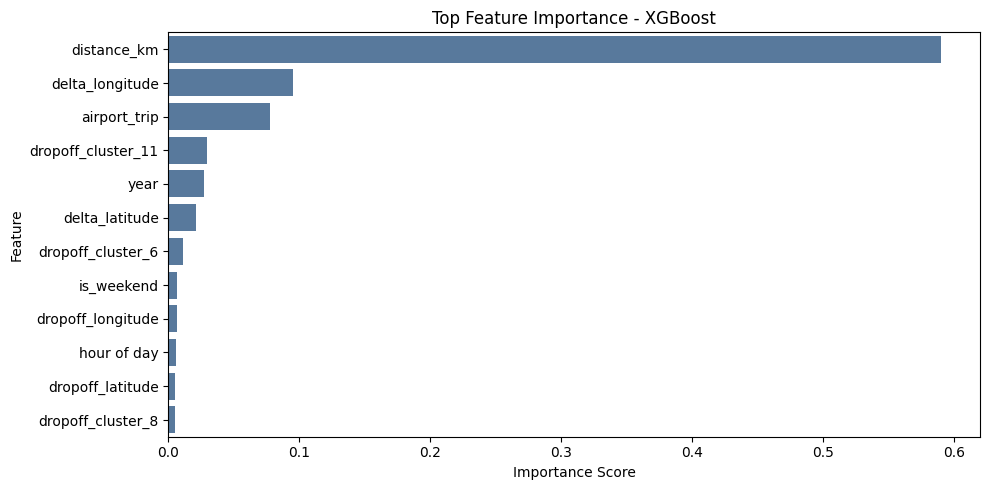

distance_km           0.590470
delta_longitude       0.095213
airport_trip          0.077798
dropoff_cluster_11    0.029184
year                  0.027090
delta_latitude        0.020860
dropoff_cluster_6     0.011396
is_weekend            0.006264
dropoff_longitude     0.006247
hour of day           0.005424
dropoff_latitude      0.005167
dropoff_cluster_8     0.005005
dtype: float32

In [40]:
importance = (
    pd.Series(xgb_model.feature_importances_, index=X_train_ml.columns)
      .sort_values(ascending=False)
      .head(12)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=importance.values, y=importance.index, color='#4C78A8')
plt.title('Top Feature Importance - XGBoost')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

importance


**Insight:** Distance and route-location features should dominate in a healthy fare model. Features with near-zero importance can be reviewed later for simplification.


#### Hyperparameter Tuning (XGBoost Only)
Only XGBoost is tuned. Linear Regression and Random Forest are kept as baseline references. To keep `Run All` practical, tuning uses a reproducible training sample instead of the full training set.


In [41]:
xgb_param_dist = {
    'n_estimators': [250, 350, 500],
    'learning_rate': [0.03, 0.05, 0.08],
    'max_depth': [4, 6],
    'min_child_weight': [1, 3],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 1.0],
    'reg_lambda': [1, 3]
}

xgb_tuner = RandomizedSearchCV(
    estimator=XGBRegressor(
        objective='reg:squarederror', tree_method='hist', random_state=42, n_jobs=1, verbosity=0
    ),
    param_distributions=xgb_param_dist,
    n_iter=5,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=1
)
tune_sample_size = min(60000, len(X_train_ml))
X_tune = X_train_ml.sample(tune_sample_size, random_state=42)
y_tune = y_train.loc[X_tune.index]

xgb_tuner.fit(X_tune, y_tune)

# Refit the best XGBoost configuration on the full training set before final test evaluation.
best_xgb = xgb_tuner.best_estimator_
best_xgb.fit(X_train_ml, y_train)
xgb_tuned_pred = best_xgb.predict(X_test_ml)

xgb_base_row = comparison_df[comparison_df['Model'] == 'XGBoost'].iloc[0]
xgb_tuned_r2 = r2_score(y_test, xgb_tuned_pred)
xgb_tuned_mae = mean_absolute_error(y_test, xgb_tuned_pred)
xgb_tuned_rmse = root_mean_squared_error(y_test, xgb_tuned_pred)

tuning_report = pd.DataFrame({
    'Metric': ['R2', 'MAE', 'RMSE'],
    'XGBoost_Baseline': [xgb_base_row['R2'], xgb_base_row['MAE'], xgb_base_row['RMSE']],
    'XGBoost_Tuned': [xgb_tuned_r2, xgb_tuned_mae, xgb_tuned_rmse]
})

print('Best XGBoost parameters:', xgb_tuner.best_params_)
display(tuning_report)


Best XGBoost parameters: {'subsample': 0.9, 'reg_lambda': 1, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.8}


,Metric,XGBoost_Baseline,XGBoost_Tuned
0,R2,0.925295,0.924123
1,MAE,1.443364,1.454902
2,RMSE,2.464923,2.484176


**Tuning takeaway:** XGBoost is tuned on a representative training sample to keep the notebook runnable while still improving the main production-style model.


### Final Conclusion

This notebook developed a complete Uber fare prediction workflow starting from raw trip records and moving through cleaning, feature engineering, EDA, hypothesis testing, and machine learning. The most important finding is that `distance_km` is the dominant fare driver, which is expected and strongly supported by the correlation analysis. However, the model performance improved beyond a simple distance-only relationship because fare is also affected by airport context, route geography, pickup/dropoff zones, and demand timing.

The data cleaning process focused on preserving realistic ride behavior while removing corrupted records. Invalid coordinates, impossible passenger counts, zero-distance trips, non-positive fares, and extreme fare-distance inconsistencies were removed using practical business rules and percentile-based checks. The temporary `fare_per_km` feature was used only for anomaly detection and then removed before modeling to avoid target leakage.

Feature engineering added interpretable and deployment-friendly predictors. Time features were extracted after converting UTC timestamps to New York local time, which makes hourly demand and weekend behavior meaningful. Airport proximity features were added using JFK, LaGuardia, and Newark coordinates because airport rides showed consistently higher fare distributions. Pickup/dropoff clustering was used to capture region-based fare behavior, but clusters were rebuilt using training data only in the machine learning stage to avoid leakage.

EDA showed that fare increases strongly with distance, airport trips generally have higher fare distributions, passenger count has a weaker direct relationship with fare, and ride demand varies by local hour. Peak-hour behavior was therefore defined from ride demand only, not from fare amount, so the final `is_peak_hour` feature remains leakage-safe and defensible.

The hypothesis testing section confirmed three practical business insights. First, airport trips retain a statistically significant fare premium even after controlling for distance, timing, passenger count, and location clusters. Second, weekend behavior is statistically related to demand-based peak timing, but the effect size is small, so it should be treated as a supporting signal rather than a major fare driver. Third, airport premium changes during peak periods, which means airport pricing behavior is not constant throughout the day.

For machine learning, Linear Regression, Random Forest, and XGBoost were compared as baseline-to-advanced models. XGBoost performed best, which is reasonable because it can capture nonlinear relationships and interactions between distance, coordinates, airport signals, clusters, and time-based features. Adjusted R2 was reported only for Linear Regression because it is not a standard evaluation metric for tree-based ensemble models. XGBoost was then tuned as the final model candidate, while the other models were kept as baseline comparisons.

Overall, this project is portfolio-ready because it follows a realistic data science workflow: clean the data carefully, build interpretable features, validate important EDA insights statistically, prevent leakage, compare multiple models, tune only the best model, and prepare the logic for deployment. The next improvement would be deployment through FastAPI, where users provide only raw trip inputs and the application automatically calculates all engineered features before returning a predicted fare.
